In [32]:
from rdkit import Chem
from rdkit.Chem import Draw, Descriptors, Descriptors3D
from rdkit.Chem import AllChem, rdMolDescriptors
from pathlib import Path
from collections import defaultdict
import pandas as pd
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
from itertools import cycle
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import (
    AgglomerativeClustering,
)
from sklearn.mixture import GaussianMixture
import os
os.environ["PATH"] += os.pathsep + "/opt/homebrew/bin/"  # Or the actual Homebrew bin directory


# Load data and features

In [33]:
########################### MAIN ##########################
# Global parameter settings
random_seed = 21
# Load data
data = pd.read_excel('../data/ALL_molecules_final_20251102.xlsx')
data['SMILES'] = data['SMILES'].apply(lambda x: Chem.MolToSmiles(Chem.MolFromSmiles(x)))
# data_ref = pd.read_excel('../data/ANCHOR_molecules.xlsx')
# data_ref['SMILES'] = data_ref['SMILES'].apply(lambda x: Chem.MolToSmiles(Chem.MolFromSmiles(x)))

In [34]:
def data_norm(df):
    '''Input is a DataFrame; only numeric features are normalized.
    '''
    numeric_cols = df.select_dtypes(include="number").columns
    scaler = MinMaxScaler()
    df[numeric_cols] = scaler.fit_transform(
        df[numeric_cols]
    )
    return df
# 0. Reload stored features and concatenate data with the same feature set

data_descriptors_TYPE1 = pd.read_excel('../data/data_descriptors_TYPE1.xlsx')
data_descriptors_TYPE2 = pd.read_excel('../data/data_descriptors_TYPE2.xlsx')
data_ref_descriptors_TYPE1 = pd.read_excel('../data/data_ref_descriptors_TYPE1.xlsx')
data_ref_descriptors_TYPE2 = pd.read_excel('../data/data_ref_descriptors_TYPE2.xlsx')

n_data = len(data_descriptors_TYPE1)  # Record the number of samples
n_data_ref = len(data_ref_descriptors_TYPE1)


combined_TYPE1 = pd.concat(
    [data_descriptors_TYPE1, data_ref_descriptors_TYPE1],
    axis=0,
    ignore_index=True,
)                                                                   # Concatenate by rows
combined_TYPE2 = pd.concat(
    [data_descriptors_TYPE2, data_ref_descriptors_TYPE2],
    axis=0,
    ignore_index=True,
)                                                                   # Concatenate by rows

# 1. Feature normalization

combined_TYPE1_norm = data_norm(combined_TYPE1) # Normalize the combined data to keep min/max values consistent
combined_TYPE2_norm = data_norm(combined_TYPE2)
data_descriptors_TYPE1_norm = combined_TYPE1_norm.iloc[:n_data].reset_index(drop=True) # Split back into two DataFrames by original size
data_ref_descriptors_TYPE1_norm = combined_TYPE1_norm.iloc[n_data : n_data + n_data_ref].reset_index(drop=True)
data_descriptors_TYPE2_norm = combined_TYPE2_norm.iloc[:n_data].reset_index(drop=True)
data_ref_descriptors_TYPE2_norm = combined_TYPE2_norm.iloc[n_data : n_data + n_data_ref].reset_index(drop=True)

X_TYPE1_scaled = data_descriptors_TYPE1_norm.select_dtypes(include="number")   # Select numeric features only
X_TYPE2_scaled = data_descriptors_TYPE2_norm.select_dtypes(include="number")   # Select numeric features only
X_ref_TYPE1_scaled = data_ref_descriptors_TYPE1_norm.select_dtypes(include="number")   # Select numeric features only
X_ref_TYPE2_scaled = data_ref_descriptors_TYPE2_norm.select_dtypes(include="number")   # Select numeric features only

# Optional: standardize first so each column has mean 0 and variance 1, reducing scale effects on distance
# scaler = StandardScaler()
# X_TYPE1_scaled = scaler.fit_transform(X_TYPE1_scaled)
# X_TYPE2_scaled = scaler.fit_transform(X_TYPE2_scaled)

del n_data, n_data_ref, combined_TYPE1, combined_TYPE1_norm, combined_TYPE2, combined_TYPE2_norm, data_descriptors_TYPE1, data_descriptors_TYPE2, data_ref_descriptors_TYPE1, data_ref_descriptors_TYPE2


In [35]:
import numpy as np
from collections import Counter, defaultdict

# Requires scipy + plotly; exporting vector images requires kaleido
# pip install scipy plotly kaleido
from scipy.cluster.hierarchy import cut_tree
import plotly.graph_objects as go


In [36]:
def sklearn_agglomerative_to_linkage(model):
    """
    Convert sklearn AgglomerativeClustering (with distances_) to SciPy linkage matrix Z.
    Z: shape (n_samples-1, 4), each row: [idx1, idx2, dist, sample_count]
    """
    children = model.children_.astype(int)
    distances = model.distances_.astype(float)
    n_samples = model.labels_.shape[0]

    counts = np.zeros(children.shape[0], dtype=float)
    for i, (a, b) in enumerate(children):
        cnt = 0
        cnt += 1 if a < n_samples else counts[a - n_samples]
        cnt += 1 if b < n_samples else counts[b - n_samples]
        counts[i] = cnt

    Z = np.column_stack([children, distances, counts])
    return Z


In [37]:
def get_level_partitions(Z, levels):
    """
    For each k in levels, return labels_k of shape (n_samples,).
    Note: cut_tree returns labels starting from 0.
    """
    parts = {}
    for k in levels:
        lab = cut_tree(Z, n_clusters=k).reshape(-1).astype(int)
        parts[k] = lab
    return parts


# Supplementary Fig.50：A hierarchical cluster dendrogram based on chemical inertness

In [38]:
model = AgglomerativeClustering(
    n_clusters=7,         # Or set to the desired number of clusters
    # distance_threshold=0,    # Use this for the full tree
    metric="euclidean",      # compute_distances currently supports only Euclidean distance
    linkage="ward",          # Other linkage methods are also possible
    compute_distances=True
)
model.fit(X_TYPE1_scaled)
# for (child_a, child_b), distance in zip(model.children_, model.distances_):
#     print(child_a, child_b, distance)

,n_clusters,7
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,True


In [39]:
sample_names = [f"sample_{i:03d}" for i in range(X_TYPE1_scaled.shape[0])]
print(sample_names)
# Or use the real sample name list (recommended)
sample_names = list(data['SMILES'])
print(sample_names)

['sample_000', 'sample_001', 'sample_002', 'sample_003', 'sample_004', 'sample_005', 'sample_006', 'sample_007', 'sample_008', 'sample_009', 'sample_010', 'sample_011', 'sample_012', 'sample_013', 'sample_014', 'sample_015', 'sample_016', 'sample_017', 'sample_018', 'sample_019', 'sample_020', 'sample_021', 'sample_022', 'sample_023', 'sample_024', 'sample_025', 'sample_026', 'sample_027', 'sample_028', 'sample_029', 'sample_030', 'sample_031', 'sample_032', 'sample_033', 'sample_034', 'sample_035', 'sample_036', 'sample_037', 'sample_038', 'sample_039', 'sample_040', 'sample_041', 'sample_042', 'sample_043', 'sample_044', 'sample_045', 'sample_046', 'sample_047', 'sample_048', 'sample_049', 'sample_050', 'sample_051', 'sample_052', 'sample_053', 'sample_054', 'sample_055', 'sample_056', 'sample_057', 'sample_058', 'sample_059', 'sample_060', 'sample_061', 'sample_062', 'sample_063', 'sample_064', 'sample_065', 'sample_066', 'sample_067', 'sample_068', 'sample_069', 'sample_070', 'samp

In [40]:
def build_sankey_from_partitions(
    partitions, levels, sample_names, X,
    final_k=7, max_show=15, show_distance=True
):
    """
    Add interactive hover text: show sample names within each node.
    Sort samples by distance to cluster centroid (ascending): more "typical" first.
    """
    n = len(sample_names)
    sample_names = np.asarray(sample_names).astype(str)
    X = np.asarray(X)
    assert X.shape[0] == n, "X and sample_names must have the same number of samples."

    final_labels = partitions[final_k]

    node_id = {}
    node_labels = []
    node_level = []
    nodes_by_level = {}

    node_hover_text = []

    idx = 0
    for k in levels:
        labs = partitions[k]
        uniq = sorted(set(labs.tolist()))
        nodes_by_level[k] = uniq

        for c in uniq:
            key = (k, c)
            node_id[key] = idx
            node_labels.append(f"L{k}-C{c}")
            node_level.append(k)

            members = np.where(labs == c)[0]
            Xm = X[members]

            # centroid distance sorting (typical first)
            centroid = Xm.mean(axis=0, keepdims=True)
            dists = np.linalg.norm(Xm - centroid, axis=1)
            order = np.argsort(dists)
            members_sorted = members[order]
            names_sorted = sample_names[members_sorted].tolist()

            # optional: show distances for the displayed samples (helps interpret "typical")
            if show_distance:
                shown = [
                    f"{nm}  (d={dists[order[i]]:.3g})"
                    for i, nm in enumerate(names_sorted[:max_show])
                ]
            else:
                shown = names_sorted[:max_show]

            suffix = "" if len(names_sorted) <= max_show else f"<br>... (+{len(names_sorted)-max_show} more)"
            hover = (
                f"<b>L{k}-C{c}</b><br>"
                # f"<b>L{k}-K{c}</b><br>"
                f"n={len(names_sorted)}<br>"
                "sorted by centroid distance (typical → atypical)<br>"
                + "<br>".join(shown)
                + suffix
            )
            node_hover_text.append(hover)

            idx += 1

    # majority color inheritance (unchanged)
    from collections import Counter
    dominant_final = {}
    for k in levels:
        labs = partitions[k]
        for c in nodes_by_level[k]:
            members = np.where(labs == c)[0]
            dom = Counter(final_labels[members].tolist()).most_common(1)[0][0]
            dominant_final[(k, c)] = dom

    # edges (unchanged)
    sources, targets, values = [], [], []
    for i in range(len(levels) - 1):
        k1, k2 = levels[i], levels[i + 1]
        lab1, lab2 = partitions[k1], partitions[k2]
        flow = defaultdict(int)
        for s in range(n):
            flow[(lab1[s], lab2[s])] += 1
        for (c1, c2), v in flow.items():
            sources.append(node_id[(k1, c1)])
            targets.append(node_id[(k2, c2)])
            values.append(v)

    return {
        "node_id": node_id,
        "node_labels": node_labels,
        "node_level": node_level,
        "node_hover_text": node_hover_text,   # used by plot_alluvial_tree_sankey
        "dominant_final": dominant_final,
        "sources": sources,
        "targets": targets,
        "values": values,
    }


In [41]:
def plot_alluvial_tree_sankey(sankey_data, levels, palette=None, title="Hierarchical clustering (alluvial tree)"):
    if palette is None:
        palette = ["#4E79A7", "#F28E2B", "#59A14F", "#E15759", "#B07AA1", "#76B7B2", "#9C755F"]

    node_colors = []
    for lab in sankey_data["node_labels"]:
        k = int(lab.split("-")[0][1:])
        c = int(lab.split("-")[1][1:])
        dom = sankey_data["dominant_final"][(k, c)]
        node_colors.append(palette[dom % len(palette)])

    fig = go.Figure(data=[go.Sankey(
        arrangement="snap",
        node=dict(
            pad=10,
            thickness=14,
            line=dict(color="rgba(0,0,0,0.15)", width=0.5),
            label=sankey_data["node_labels"],
            color=node_colors,

            # NEW: pass per-node hover text
            customdata=sankey_data["node_hover_text"],
            hovertemplate="%{customdata}<extra></extra>",
        ),
        link=dict(
            source=sankey_data["sources"],
            target=sankey_data["targets"],
            value=sankey_data["values"],
            color="rgba(0,0,0,0.15)",
            hovertemplate="flow=%{value}<extra></extra>",
        )
    )])

    fig.update_layout(
        title=title,
        font=dict(family="Helvetica", size=20, color="black"),
        paper_bgcolor="white",
        plot_bgcolor="white",
        margin=dict(l=10, r=10, t=45, b=10),
        width=980,
        height=520,
    )
    return fig


In [42]:
Z = sklearn_agglomerative_to_linkage(model)
levels = [1, 2, 4, 7]
parts = get_level_partitions(Z, levels)

# sample_names: sample name list with length 260
sdata = build_sankey_from_partitions(
    parts, levels,
    sample_names=sample_names,
    X=X_TYPE1_scaled,
    final_k=7,
    max_show=10,
    show_distance=True
)

fig = plot_alluvial_tree_sankey(sdata, levels, title="Fig. 50 | A hierarchical cluster dendrogram based on chemical inertness.")
fig.show()

import plotly.io as pio  # Import once at the top of the file if preferred
# After each fig is generated
# fig.write_image("alluvial_tree.png", width=1800, height=900, scale=2)  # Increase scale/width/height as needed
fig.write_image("../result/Fig.50 | A hierarchical cluster dendrogram based on chemical inertness.svg")  # Export another copy when a vector image is needed

# Supplementary Fig.51：A hierarchical cluster dendrogram based on viscosity.

In [43]:
model = AgglomerativeClustering(
    n_clusters=7,         # Or set to the desired number of clusters
    # distance_threshold=0,    # Use this for the full tree
    metric="euclidean",      # compute_distances currently supports only Euclidean distance
    linkage="ward",          # Other linkage methods are also possible
    compute_distances=True
)
model.fit(X_TYPE2_scaled)
# for (child_a, child_b), distance in zip(model.children_, model.distances_):
#     print(child_a, child_b, distance)

,n_clusters,7
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,True


In [44]:
sample_names = [f"sample_{i:03d}" for i in range(X_TYPE2_scaled.shape[0])]
print(sample_names)
# Or use the real sample name list (recommended)
sample_names = list(data['SMILES'])
print(sample_names)

['sample_000', 'sample_001', 'sample_002', 'sample_003', 'sample_004', 'sample_005', 'sample_006', 'sample_007', 'sample_008', 'sample_009', 'sample_010', 'sample_011', 'sample_012', 'sample_013', 'sample_014', 'sample_015', 'sample_016', 'sample_017', 'sample_018', 'sample_019', 'sample_020', 'sample_021', 'sample_022', 'sample_023', 'sample_024', 'sample_025', 'sample_026', 'sample_027', 'sample_028', 'sample_029', 'sample_030', 'sample_031', 'sample_032', 'sample_033', 'sample_034', 'sample_035', 'sample_036', 'sample_037', 'sample_038', 'sample_039', 'sample_040', 'sample_041', 'sample_042', 'sample_043', 'sample_044', 'sample_045', 'sample_046', 'sample_047', 'sample_048', 'sample_049', 'sample_050', 'sample_051', 'sample_052', 'sample_053', 'sample_054', 'sample_055', 'sample_056', 'sample_057', 'sample_058', 'sample_059', 'sample_060', 'sample_061', 'sample_062', 'sample_063', 'sample_064', 'sample_065', 'sample_066', 'sample_067', 'sample_068', 'sample_069', 'sample_070', 'samp

In [45]:
def build_sankey_from_partitions(
    partitions, levels, sample_names, X,
    final_k=7, max_show=15, show_distance=True
):
    """
    Add interactive hover text: show sample names within each node.
    Sort samples by distance to cluster centroid (ascending): more "typical" first.
    """
    n = len(sample_names)
    sample_names = np.asarray(sample_names).astype(str)
    X = np.asarray(X)
    assert X.shape[0] == n, "X and sample_names must have the same number of samples."

    final_labels = partitions[final_k]

    node_id = {}
    node_labels = []
    node_level = []
    nodes_by_level = {}

    node_hover_text = []

    idx = 0
    for k in levels:
        labs = partitions[k]
        uniq = sorted(set(labs.tolist()))
        nodes_by_level[k] = uniq

        for c in uniq:
            key = (k, c)
            node_id[key] = idx
            node_labels.append(f"L{k}-K{c}")
            node_level.append(k)

            members = np.where(labs == c)[0]
            Xm = X[members]

            # centroid distance sorting (typical first)
            centroid = Xm.mean(axis=0, keepdims=True)
            dists = np.linalg.norm(Xm - centroid, axis=1)
            order = np.argsort(dists)
            members_sorted = members[order]
            names_sorted = sample_names[members_sorted].tolist()

            # optional: show distances for the displayed samples (helps interpret "typical")
            if show_distance:
                shown = [
                    f"{nm}  (d={dists[order[i]]:.3g})"
                    for i, nm in enumerate(names_sorted[:max_show])
                ]
            else:
                shown = names_sorted[:max_show]

            suffix = "" if len(names_sorted) <= max_show else f"<br>... (+{len(names_sorted)-max_show} more)"
            hover = (
                # f"<b>L{k}-C{c}</b><br>"
                f"<b>L{k}-K{c}</b><br>"
                f"n={len(names_sorted)}<br>"
                "sorted by centroid distance (typical → atypical)<br>"
                + "<br>".join(shown)
                + suffix
            )
            node_hover_text.append(hover)

            idx += 1

    # majority color inheritance (unchanged)
    from collections import Counter
    dominant_final = {}
    for k in levels:
        labs = partitions[k]
        for c in nodes_by_level[k]:
            members = np.where(labs == c)[0]
            dom = Counter(final_labels[members].tolist()).most_common(1)[0][0]
            dominant_final[(k, c)] = dom

    # edges (unchanged)
    sources, targets, values = [], [], []
    for i in range(len(levels) - 1):
        k1, k2 = levels[i], levels[i + 1]
        lab1, lab2 = partitions[k1], partitions[k2]
        flow = defaultdict(int)
        for s in range(n):
            flow[(lab1[s], lab2[s])] += 1
        for (c1, c2), v in flow.items():
            sources.append(node_id[(k1, c1)])
            targets.append(node_id[(k2, c2)])
            values.append(v)

    return {
        "node_id": node_id,
        "node_labels": node_labels,
        "node_level": node_level,
        "node_hover_text": node_hover_text,   # used by plot_alluvial_tree_sankey
        "dominant_final": dominant_final,
        "sources": sources,
        "targets": targets,
        "values": values,
    }


In [46]:
Z = sklearn_agglomerative_to_linkage(model)
levels = [1, 2, 4, 7]
parts = get_level_partitions(Z, levels)

# sample_names: sample name list with length 260
sdata = build_sankey_from_partitions(
    parts, levels,
    sample_names=sample_names,
    X=X_TYPE2_scaled,
    final_k=7,
    max_show=10,
    show_distance=True
)

fig = plot_alluvial_tree_sankey(sdata, levels, title="Fig. 51 | A hierarchical cluster dendrogram based on viscosity.")
fig.show()

import plotly.io as pio  # Import once at the top of the file if preferred
# After each fig is generated
# fig.write_image("alluvial_tree.png", width=1800, height=900, scale=2)  # Increase scale/width/height as needed
fig.write_image("../result/Fig.51 | A hierarchical cluster dendrogram based on viscosity.svg")  # Export another copy when a vector image is needed

# Supplementary Fig.52：t-SNE visualization of clustered molecules in descriptor space

In [47]:
def plot_tsne_scatter(
    csv_path,
    title,
    out_html=None,
    palette=None,
):
    """
    Interactive t-SNE scatter plot from a CSV with tsne_1, tsne_2, label, and name columns.
    """
    if palette is None:
        palette = ["#4E79A7", "#F28E2B", "#59A14F", "#E15759", "#B07AA1", "#76B7B2", "#9C755F"]

    df = pd.read_csv(csv_path).copy()
    required_cols = {"tsne_1", "tsne_2", "label", "name"}
    missing_cols = required_cols - set(df.columns)
    if missing_cols:
        raise ValueError(f"Missing required columns in {csv_path}: {sorted(missing_cols)}")

    df["label_display"] = df["label"].map(lambda x: f"C{x}")

    def label_sort_key(value):
        try:
            return (0, float(value))
        except (TypeError, ValueError):
            return (1, str(value))

    labels = sorted(df["label"].unique().tolist(), key=label_sort_key)
    color_map = {label: palette[i % len(palette)] for i, label in enumerate(labels)}

    fig = go.Figure()
    for label in labels:
        sub = df[df["label"] == label]
        customdata = np.column_stack([
            sub["name"].astype(str),
            sub["label_display"].astype(str),
        ])
        fig.add_trace(go.Scatter(
            x=sub["tsne_1"],
            y=sub["tsne_2"],
            mode="markers",
            name=f"C{label}",
            customdata=customdata,
            marker=dict(
                color=color_map[label],
                size=8,
                opacity=0.85,
                line=dict(color="rgba(0,0,0,0.25)", width=0.4),
            ),
            hovertemplate=(
                "<b>%{customdata[0]}</b><br>"
                "label=%{customdata[1]}<br>"
                "tsne_1=%{x:.3f}<br>"
                "tsne_2=%{y:.3f}"
                "<extra></extra>"
            ),
        ))

    fig.update_layout(
        title=title,
        font=dict(family="Helvetica", size=16, color="black"),
        paper_bgcolor="white",
        plot_bgcolor="white",
        margin=dict(l=60, r=20, t=55, b=55),
        width=760,
        height=620,
        legend=dict(title="Cluster", itemsizing="constant"),
    )
    fig.update_xaxes(
        title_text="t-SNE 1",
        showline=True,
        linewidth=1,
        linecolor="black",
        mirror=True,
        zeroline=False,
    )
    fig.update_yaxes(
        title_text="t-SNE 2",
        showline=True,
        linewidth=1,
        linecolor="black",
        mirror=True,
        zeroline=False,
    )

    if out_html is not None:
        fig.write_html(out_html, include_plotlyjs="cdn")

    return fig


fig52_type1 = plot_tsne_scatter(
    "../data/TYPE1-tsne-feature.csv",
    title="Fig.52(a) | t-SNE visualization of clustered molecules in chemical inertness descriptor space",
    out_html="../result/Fig.52(a) | t-SNE chemical inertness.html",
)
fig52_type1.show()


fig52_type2 = plot_tsne_scatter(
    "../data/TYPE2-tsne-feature.csv",
    title="Fig.52(b) | t-SNE visualization of clustered molecules in viscosity descriptor space",
    out_html="../result/Fig.52(b) | t-SNE viscosity.html",
)
fig52_type2.show()


# Supplementary Fig.53(a): Cluster centroid heatmap of the standardized chemical inertness.

In [48]:
# Feature heatmap visualization

def eta_squared_per_feature(X: np.ndarray, y: np.ndarray) -> np.ndarray:
    """
    Effect size η² per feature: between-cluster variance / total variance.
    X: (n, d) standardized features
    y: (n,) cluster labels
    """
    X = np.asarray(X, dtype=float)
    y = np.asarray(y)
    n, d = X.shape

    overall_mean = X.mean(axis=0, keepdims=True)
    ss_total = ((X - overall_mean) ** 2).sum(axis=0)

    ss_within = np.zeros(d)
    for c in np.unique(y):
        Xc = X[y == c]
        mc = Xc.mean(axis=0, keepdims=True)
        ss_within += ((Xc - mc) ** 2).sum(axis=0)

    ss_between = ss_total - ss_within
    eta2 = ss_between / (ss_total + 1e-12)
    return eta2


def cluster_centroids(X: np.ndarray, y: np.ndarray) -> np.ndarray:
    """
    Cluster-wise means.
    Returns (K, d) ordered by sorted unique labels.
    """
    X = np.asarray(X, dtype=float)
    y = np.asarray(y)
    classes = sorted(np.unique(y).tolist())
    C = np.vstack([X[y == c].mean(axis=0) for c in classes])
    return C, classes

def plot_cluster_centroid_profiles(
    X_df: pd.DataFrame,
    labels: np.ndarray,
    feature_order=None,              # Optional order; if not provided, sort automatically by eta2
    out_prefix: str = "fig_centroid_profiles",
    cmap: str = "RdBu_r",
):
    X = X_df.to_numpy(dtype=float)
    feat_names = X_df.columns.to_list()

    eta2 = eta_squared_per_feature(X, labels)
    C, classes = cluster_centroids(X, labels)

    if feature_order is None:
        order = np.argsort(-eta2)
    else:
        # feature_order: list of column names in desired order
        name2idx = {n:i for i,n in enumerate(feat_names)}
        order = np.array([name2idx[n] for n in feature_order], dtype=int)

    C_s = C[:, order]
    names_s = [feat_names[i] for i in order]

    # Use full data range (as requested): global min/max over the heatmap matrix
    vmin = float(np.nanmin(C_s))
    vmax = float(np.nanmax(C_s))

    # Avoid imshow errors when vmin == vmax in the edge case where all values are identical
    if np.isclose(vmin, vmax):
        eps = 1e-6 if vmin == 0 else abs(vmin) * 1e-6
        vmin -= eps
        vmax += eps

    plt.figure(figsize=(12.8, 6.4))
    ax = plt.gca()
    im = ax.imshow(C_s, aspect="auto", vmin=vmin, vmax=vmax, cmap="YlGn")

    ax.set_yticks(range(len(classes)))
    ax.set_yticklabels([f"C{c}" for c in classes], fontname="Arial", fontsize=20)
    ax.set_xticks(range(len(names_s)))
    ax.set_xticklabels([str(i) for i in range(1, len(names_s) + 1)], rotation=0, ha="center", fontname="Arial", fontsize=20)
    # ax.set_title("Cluster centroid profiles (standardized features)", pad=10)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    from matplotlib.ticker import MaxNLocator
    cbar = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.set_label("Mean (scaled)", rotation=90, fontname="Arial", fontsize=20)
    cbar.ax.tick_params(labelsize=20, width=0.6, length=3)


    # Keep ticks clean: at most 5 major ticks
    cbar.locator = MaxNLocator(nbins=5)
    cbar.update_ticks()

    # Styling: remove or thin the outer border
    cbar.outline.set_linewidth(0.6)
    # Make ticks thinner and more restrained
    cbar.ax.tick_params(width=0.6, length=3)

    plt.tight_layout()

    pdf = f"{out_prefix}.pdf"
    svg = f"{out_prefix}.svg"
    plt.savefig(pdf, dpi=300, bbox_inches="tight")
    plt.savefig(svg, bbox_inches="tight")
    plt.show()
    return {"paths": (pdf, svg), "feature_order": names_s}



In [49]:
model = AgglomerativeClustering(
    n_clusters=7,         # Or set to the desired number of clusters
    # distance_threshold=0,    # Use this for the full tree
    metric="euclidean",      # compute_distances currently supports only Euclidean distance
    linkage="ward",          # Other linkage methods are also possible
    compute_distances=True
)
model.fit(X_TYPE1_scaled)
# for (child_a, child_b), distance in zip(model.children_, model.distances_):
#     print(child_a, child_b, distance)

,n_clusters,7
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,True


In [50]:

X_df = X_TYPE1_scaled.copy()
labels = model.fit_predict(X_TYPE1_scaled)
labels = np.asarray(labels)  # Or use: labels = model.labels_



In [51]:
seq_path = "../data/RDKit_TYPE1_sequence.csv"
seq_df = pd.read_csv(seq_path)

# Use CSV columns as the requested feature-name order
feature_order = list(seq_df.columns)

# Validate alignment with X_TYPE2_scaled column names
x_cols = list(X_TYPE1_scaled.columns)
x_set = set(x_cols)
ord_set = set(feature_order)

missing_in_X = [c for c in feature_order if c not in x_set]     # Present in CSV but missing from X
extra_in_X   = [c for c in x_cols if c not in ord_set]          # Present in X but missing from CSV

print("feature_order length (from CSV columns):", len(feature_order))
print("X columns:", len(x_cols))

if missing_in_X:
    print("[WARN] These columns are in sequence CSV but NOT in X_TYPE2_scaled:", missing_in_X)

if extra_in_X:
    print("[WARN] These columns are in X_TYPE2_scaled but NOT in sequence CSV:", extra_in_X)

# Final plotting order: keep only columns that exist in X, following the CSV order
feature_order = [c for c in feature_order if c in x_set]

print("Final feature_order used for plotting:", len(feature_order))

feature_order length (from CSV columns): 21
X columns: 21
Final feature_order used for plotting: 21


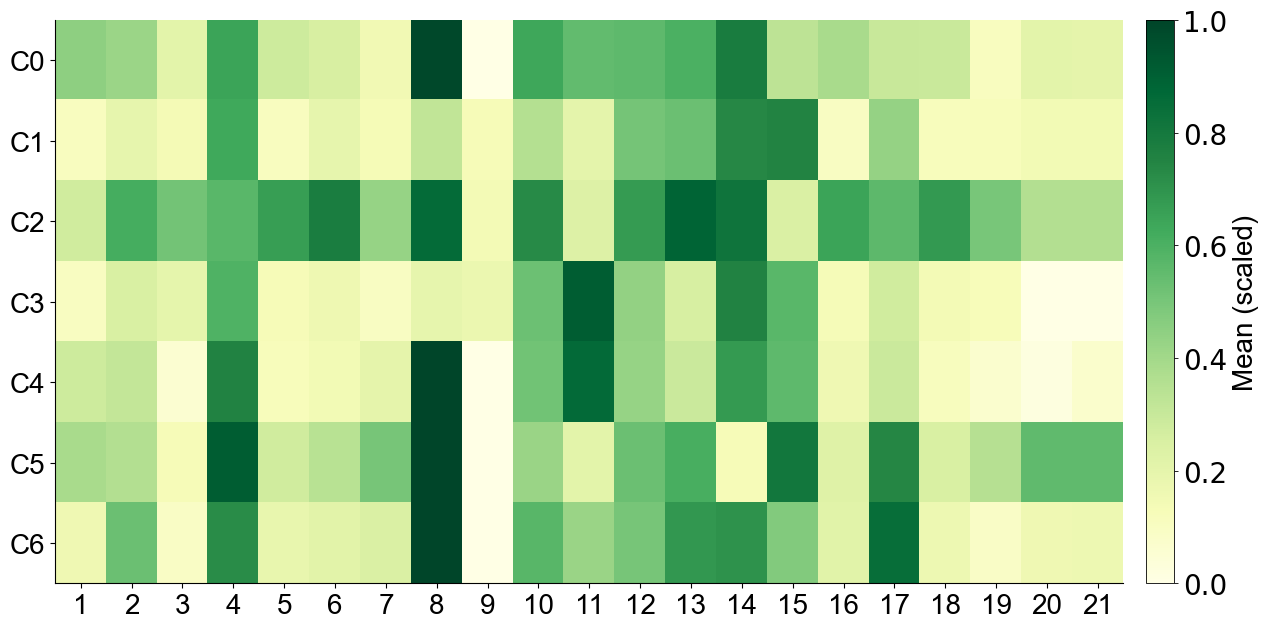

('../result/Fig.53(a) | Cluster centroid heatmap of the standardized chemical inertness..pdf', '../result/Fig.53(a) | Cluster centroid heatmap of the standardized chemical inertness..svg')


In [52]:

res1 = plot_cluster_centroid_profiles(
    X_TYPE1_scaled, labels,
    feature_order=feature_order,
    out_prefix="../result/Fig.53(a) | Cluster centroid heatmap of the standardized chemical inertness."
)

print(res1["paths"])


# Supplementary Fig.53(b): Cluster centroid heatmap of the standardized viscosity descriptors.

In [53]:
# Feature heatmap visualization

def eta_squared_per_feature(X: np.ndarray, y: np.ndarray) -> np.ndarray:
    """
    Effect size η² per feature: between-cluster variance / total variance.
    X: (n, d) standardized features
    y: (n,) cluster labels
    """
    X = np.asarray(X, dtype=float)
    y = np.asarray(y)
    n, d = X.shape

    overall_mean = X.mean(axis=0, keepdims=True)
    ss_total = ((X - overall_mean) ** 2).sum(axis=0)

    ss_within = np.zeros(d)
    for c in np.unique(y):
        Xc = X[y == c]
        mc = Xc.mean(axis=0, keepdims=True)
        ss_within += ((Xc - mc) ** 2).sum(axis=0)

    ss_between = ss_total - ss_within
    eta2 = ss_between / (ss_total + 1e-12)
    return eta2


def cluster_centroids(X: np.ndarray, y: np.ndarray) -> np.ndarray:
    """
    Cluster-wise means.
    Returns (K, d) ordered by sorted unique labels.
    """
    X = np.asarray(X, dtype=float)
    y = np.asarray(y)
    classes = sorted(np.unique(y).tolist())
    C = np.vstack([X[y == c].mean(axis=0) for c in classes])
    return C, classes

def plot_cluster_centroid_profiles(
    X_df: pd.DataFrame,
    labels: np.ndarray,
    feature_order=None,              # Optional order; if not provided, sort automatically by eta2
    out_prefix: str = "fig_centroid_profiles",
    cmap: str = "RdBu_r",
):
    X = X_df.to_numpy(dtype=float)
    feat_names = X_df.columns.to_list()

    eta2 = eta_squared_per_feature(X, labels)
    C, classes = cluster_centroids(X, labels)

    if feature_order is None:
        order = np.argsort(-eta2)
    else:
        # feature_order: list of column names in desired order
        name2idx = {n:i for i,n in enumerate(feat_names)}
        order = np.array([name2idx[n] for n in feature_order], dtype=int)

    C_s = C[:, order]
    names_s = [feat_names[i] for i in order]

    # Use full data range (as requested): global min/max over the heatmap matrix
    vmin = float(np.nanmin(C_s))
    vmax = float(np.nanmax(C_s))

    # Avoid imshow errors when vmin == vmax in the edge case where all values are identical
    if np.isclose(vmin, vmax):
        eps = 1e-6 if vmin == 0 else abs(vmin) * 1e-6
        vmin -= eps
        vmax += eps

    plt.figure(figsize=(12.8, 6.4))
    ax = plt.gca()
    im = ax.imshow(C_s, aspect="auto", vmin=vmin, vmax=vmax, cmap="YlGn")

    ax.set_yticks(range(len(classes)))
    ax.set_yticklabels([f"K{c}" for c in classes], fontname="Arial", fontsize=20)
    ax.set_xticks(range(len(names_s)))
    ax.set_xticklabels([str(i) for i in range(1, len(names_s) + 1)], rotation=0, ha="center", fontname="Arial", fontsize=20)
    # ax.set_title("Cluster centroid profiles (standardized features)", pad=10)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    from matplotlib.ticker import MaxNLocator
    cbar = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.set_label("Mean (scaled)", rotation=90, fontname="Arial", fontsize=20)
    cbar.ax.tick_params(labelsize=20, width=0.6, length=3)


    # Keep ticks clean: at most 5 major ticks
    cbar.locator = MaxNLocator(nbins=5)
    cbar.update_ticks()

    # Styling: remove or thin the outer border
    cbar.outline.set_linewidth(0.6)
    # Make ticks thinner and more restrained
    cbar.ax.tick_params(width=0.6, length=3)

    plt.tight_layout()

    pdf = f"{out_prefix}.pdf"
    svg = f"{out_prefix}.svg"
    plt.savefig(pdf, dpi=300, bbox_inches="tight")
    plt.savefig(svg, bbox_inches="tight")
    plt.show()
    return {"paths": (pdf, svg), "feature_order": names_s}



In [54]:
model = AgglomerativeClustering(
    n_clusters=7,         # Or set to the desired number of clusters
    # distance_threshold=0,    # Use this for the full tree
    metric="euclidean",      # compute_distances currently supports only Euclidean distance
    linkage="ward",          # Other linkage methods are also possible
    compute_distances=True
)
model.fit(X_TYPE2_scaled)
# for (child_a, child_b), distance in zip(model.children_, model.distances_):
#     print(child_a, child_b, distance)
X_df = X_TYPE2_scaled.copy()
labels = model.fit_predict(X_TYPE2_scaled)
labels = np.asarray(labels)  # Or use: labels = model.labels_

In [55]:
seq_path = "../data/RDKit_TYPE2_sequence.csv"
seq_df = pd.read_csv(seq_path)

# Use CSV columns as the requested feature-name order
feature_order = list(seq_df.columns)

# Validate alignment with X_TYPE2_scaled column names
x_cols = list(X_TYPE2_scaled.columns)
x_set = set(x_cols)
ord_set = set(feature_order)

missing_in_X = [c for c in feature_order if c not in x_set]     # Present in CSV but missing from X
extra_in_X   = [c for c in x_cols if c not in ord_set]          # Present in X but missing from CSV

print("feature_order length (from CSV columns):", len(feature_order))
print("X columns:", len(x_cols))

if missing_in_X:
    print("[WARN] These columns are in sequence CSV but NOT in X_TYPE2_scaled:", missing_in_X)

if extra_in_X:
    print("[WARN] These columns are in X_TYPE2_scaled but NOT in sequence CSV:", extra_in_X)

# Final plotting order: keep only columns that exist in X, following the CSV order
feature_order = [c for c in feature_order if c in x_set]

print("Final feature_order used for plotting:", len(feature_order))

feature_order length (from CSV columns): 35
X columns: 35
Final feature_order used for plotting: 35


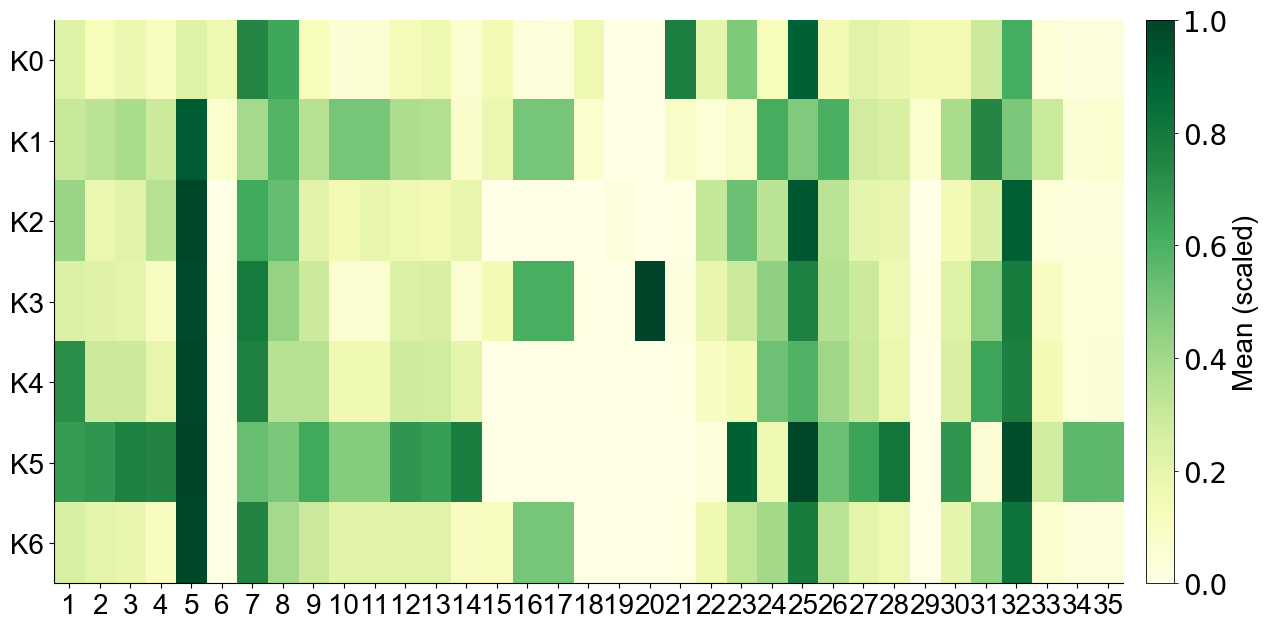

('../result/Fig.53(b) | Cluster centroid heatmap of the standardized viscosity descriptors..pdf', '../result/Fig.53(b) | Cluster centroid heatmap of the standardized viscosity descriptors..svg')


In [56]:

res1 = plot_cluster_centroid_profiles(
    X_TYPE2_scaled, labels,
    feature_order=feature_order,
    out_prefix="../result/Fig.53(b) | Cluster centroid heatmap of the standardized viscosity descriptors."
)

print(res1["paths"])


# Supplementary Fig.54(a): The analysis of molecular descriptors for clusters. Between-cluster effect size (𝜂^2) for each descriptor for chemical inertness.

In [57]:

def plot_feature_discriminability(
    X_df: pd.DataFrame,
    labels: np.ndarray,
    feature_order=None,              # Use the same order as the heatmap (recommended)
    out_prefix: str = "fig_feature_discriminability",
    use_wistia: bool = True,

):
    X = X_df.to_numpy(dtype=float)
    feat_names = X_df.columns.to_list()

    eta2 = eta_squared_per_feature(X, labels)

    if feature_order is None:
        order = np.argsort(-eta2)
        names_s = [feat_names[i] for i in order]
        eta2_s = eta2[order]
    else:
        name2idx = {n:i for i,n in enumerate(feat_names)}
        order = np.array([name2idx[n] for n in feature_order], dtype=int)
        names_s = [feat_names[i] for i in order]
        eta2_s = eta2[order]

    vals = eta2_s.astype(float)
    import matplotlib as mpl

    # Normalize to [0, 1] for colormap mapping
    norm = mpl.colors.Normalize(vmin=float(np.min(vals)), vmax=float(np.max(vals)))
    cmap = mpl.cm.get_cmap("Wistia")
    colors = cmap(norm(vals))  # shape (d,4) RGBA

    d = len(names_s)
    y = np.arange(d)

    plt.figure(figsize=(6.6, 6.2))
    ax = plt.gca()
    # ax.barh(y, eta2_s)
    ax.barh(y, eta2_s, color=colors)
    ax.set_yticks(y)
    # ax.set_yticklabels(names_s)
    ax.set_yticklabels([str(i) for i in range(1, len(names_s) + 1)], rotation=0, ha="center", fontname="Arial", fontsize=13)

    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    cbar = plt.colorbar(sm, ax=ax, fraction=0.06, pad=0.02)
    cbar.set_label(r"$\eta^2$", fontsize=11, fontname="Helvetica")
    cbar.ax.tick_params(labelsize=9, width=0.6, length=3)


    ax.invert_yaxis()
    ax.set_xlabel(r"$\eta^2$  (between-cluster effect size)")
    ax.set_title("Feature discriminability", pad=10)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", alpha=0.2)

    plt.tight_layout()

    pdf = f"{out_prefix}.pdf"
    svg = f"{out_prefix}.svg"
    plt.savefig(pdf, dpi=300, bbox_inches="tight")
    plt.savefig(svg, bbox_inches="tight")
    plt.show()
    return {"paths": (pdf, svg), "eta2": pd.Series(eta2, index=feat_names).sort_values(ascending=False)}

In [58]:
seq_path = "../data/RDKit_TYPE1_sequence.csv"
seq_df = pd.read_csv(seq_path)
feature_order = list(seq_df.columns)
model = AgglomerativeClustering(
    n_clusters=7,         # Or set to the desired number of clusters
    # distance_threshold=0,    # Use this for the full tree
    metric="euclidean",      # compute_distances currently supports only Euclidean distance
    linkage="ward",          # Other linkage methods are also possible
    compute_distances=True
)
model.fit(X_TYPE1_scaled)
# for (child_a, child_b), distance in zip(model.children_, model.distances_):
#     print(child_a, child_b, distance)
X_df = X_TYPE1_scaled.copy()
labels = model.fit_predict(X_TYPE1_scaled)
labels = np.asarray(labels)  # Or use: labels = model.labels_

/var/folders/ng/gh1z5pd94vs9k3844kydvqw00000gn/T/ipykernel_29704/2010057484.py:29: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



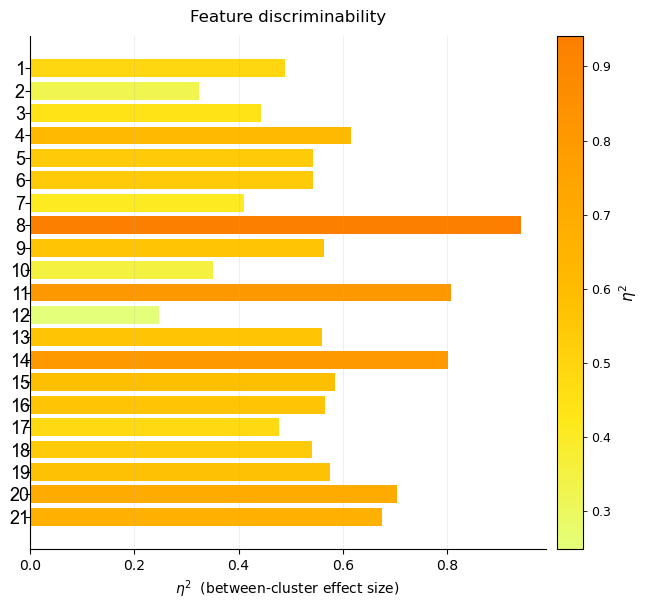

('../result/Fig.54(a) | The analysis of molecular descriptors for clusters. Between-cluster effect size (𝜂^2) for each descriptor for chemical inertness..pdf', '../result/Fig.54(a) | The analysis of molecular descriptors for clusters. Between-cluster effect size (𝜂^2) for each descriptor for chemical inertness..svg')


In [59]:
res1 = plot_feature_discriminability(
    X_TYPE1_scaled, labels,
    feature_order=feature_order,
    out_prefix="../result/Fig.54(a) | The analysis of molecular descriptors for clusters. Between-cluster effect size (𝜂^2) for each descriptor for chemical inertness."
)

print(res1["paths"])

# Supplementary Fig.54(b): The analysis of molecular descriptors for clusters. Between-cluster effect size (𝜂^2) for each descriptor for viscosity features.

In [60]:
seq_path = "../data/RDKit_TYPE2_sequence.csv"
seq_df = pd.read_csv(seq_path)
feature_order = list(seq_df.columns)
model = AgglomerativeClustering(
    n_clusters=7,         # Or set to the desired number of clusters
    # distance_threshold=0,    # Use this for the full tree
    metric="euclidean",      # compute_distances currently supports only Euclidean distance
    linkage="ward",          # Other linkage methods are also possible
    compute_distances=True
)
model.fit(X_TYPE2_scaled)
# for (child_a, child_b), distance in zip(model.children_, model.distances_):
#     print(child_a, child_b, distance)
X_df = X_TYPE2_scaled.copy()
labels = model.fit_predict(X_TYPE2_scaled)
labels = np.asarray(labels)  # Or use: labels = model.labels_

/var/folders/ng/gh1z5pd94vs9k3844kydvqw00000gn/T/ipykernel_29704/2010057484.py:29: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



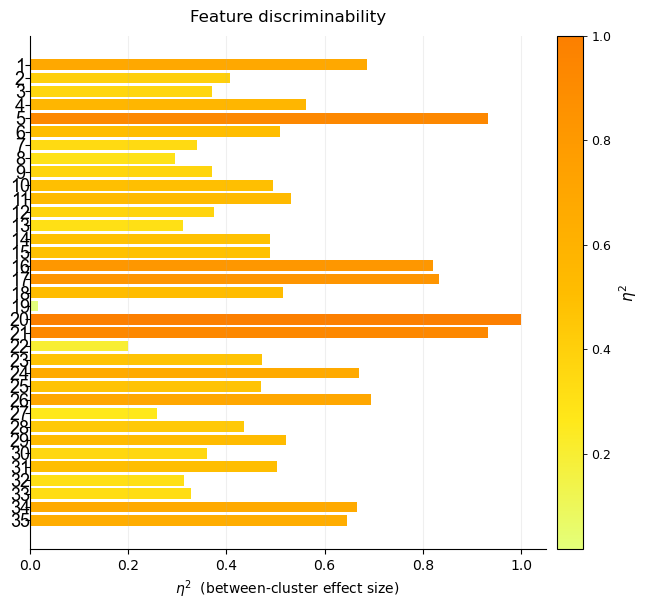

('../result/Fig.54(b) | The analysis of molecular descriptors for clusters. Between-cluster effect size (𝜂^2) for each descriptor for viscosity features..pdf', '../result/Fig.54(b) | The analysis of molecular descriptors for clusters. Between-cluster effect size (𝜂^2) for each descriptor for viscosity features..svg')


In [61]:
res2 = plot_feature_discriminability(
    X_TYPE2_scaled, labels,
    feature_order=feature_order,
    out_prefix="../result/Fig.54(b) | The analysis of molecular descriptors for clusters. Between-cluster effect size (𝜂^2) for each descriptor for viscosity features."
)

print(res2["paths"])